# **Assignment-6**
### **Name:** Vaddi Govardhan
### **Roll No:** 14202032
This notebook covers:
1. Training ResNet on Tiny ImageNet with W&B logging (5 Marks)
2. Deploying model on Hugging Face (10 Marks)
3. Simulating and detecting data drift (10 Marks)

**Hardware Used:** T4 GPU on Google Colab

## Setup and Installation

In [ ]:
# Install required packages
!pip install -q wandb torch torchvision huggingface_hub gradio
!pip install -q pillow matplotlib numpy tqdm

In [ ]:
# Import libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import wandb
from huggingface_hub import HfApi, create_repo, upload_folder
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import zipfile
import shutil
import requests
from pathlib import Path

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## Question 1 : Download Tiny ImageNet and Train ResNet with W&B (5 Marks)


### 1.1 Download and Prepare Tiny ImageNet Dataset

In [ ]:
# Download Tiny ImageNet
!wget -q http://cs231n.stanford.edu/tiny-imagenet-200.zip
!unzip -q tiny-imagenet-200.zip
print("Dataset downloaded and extracted!")

Dataset downloaded and extracted!


In [ ]:
import os, shutil
from tqdm import tqdm

val_dir = 'tiny-imagenet-200/val'
if os.path.exists(os.path.join(val_dir, 'images')):
    with open(os.path.join(val_dir, 'val_annotations.txt')) as f:
        for line in tqdm(f, desc="Fixing validation"):
            img, cls = line.split('\t')[:2]
            os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
            src = os.path.join(val_dir, 'images', img)
            if os.path.exists(src):
                shutil.move(src, os.path.join(val_dir, cls, img))
    shutil.rmtree(os.path.join(val_dir, 'images'), ignore_errors=True)
    print("✓ Fixed!")
else:
    print("✓ Already fixed!")

Fixing validation: 10000it [00:00, 30046.02it/s]

✓ Fixed!


In [ ]:
# Prepare validation set structure (Tiny ImageNet has non-standard structure)
def prepare_tiny_imagenet_val():
    val_dir = 'tiny-imagenet-200/val'
    val_annotations = os.path.join(val_dir, 'val_annotations.txt')

    # Read annotations
    val_img_dict = {}
    with open(val_annotations, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            val_img_dict[parts[0]] = parts[1]

    # Create class directories
    val_images_dir = os.path.join(val_dir, 'images')
    for img_name, class_name in val_img_dict.items():
        class_dir = os.path.join(val_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        src = os.path.join(val_images_dir, img_name)
        dst = os.path.join(class_dir, img_name)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copy(src, dst)

    print("Validation set prepared!")

prepare_tiny_imagenet_val()

Validation set prepared!


### 1.2 Define Data Transforms and Loaders

In [ ]:
# Data transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = ImageFolder('tiny-imagenet-200/train', transform=train_transform)
val_dataset = ImageFolder('tiny-imagenet-200/val', transform=val_transform)

# Data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

Training samples: 100000
Validation samples: 10000
Number of classes: 200


### 1.3 Initialize W&B and Setup Model

In [ ]:
# Login to W&B
wandb.login()

# Initialize W&B
config = {
    'model': 'ResNet18',
    'batch_size': batch_size,
    'epochs': 20,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'weight_decay': 1e-4,
    'num_classes': 200,
    'image_size': 64,
    'scheduler': 'StepLR',
    'step_size': 7,
    'gamma': 0.1
}

run = wandb.init(
    project='tiny-imagenet-resnet',
    name='resnet18-baseline',
    config=config,
    tags=['baseline', 'resnet18']
)

print("W&B initialized!")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 142502032 (ir2023) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B initialized!


In [ ]:
# Load pretrained ResNet18 and modify for Tiny ImageNet
model = models.resnet18(pretrained=True)

# Modify final layer for 200 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 200)

model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=config['step_size'], gamma=config['gamma'])

print(f"Model loaded: {config['model']}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Model loaded: ResNet18
Total parameters: 11,279,112


### 1.4 Training Loop with W&B Logging

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': f'{running_loss/total:.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({'loss': f'{running_loss/total:.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    return running_loss / len(loader), 100. * correct / total

In [ ]:
# Training loop
num_epochs = config['epochs']
best_acc = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 50)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Log to W&B
    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_accuracy': train_acc,
        'val_loss': val_loss,
        'val_accuracy': val_acc,
        'learning_rate': current_lr
    })

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {current_lr:.6f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'config': config
        }, 'best_model.pth')
        print(f"✓ Best model saved with accuracy: {best_acc:.2f}%")

print(f"\nTraining completed! Best validation accuracy: {best_acc:.2f}%")


Epoch 1/20
--------------------------------------------------


Validation: 100%|██████████| 79/79 [00:06<00:00, 12.99it/s, loss=0.0227, acc=32.22%]


Train Loss: 3.2446 | Train Acc: 26.15%
Val Loss: 2.8766 | Val Acc: 32.22%
Learning Rate: 0.001000
✓ Best model saved with accuracy: 32.22%

Epoch 2/20
--------------------------------------------------


Validation: 100%|██████████| 79/79 [00:04<00:00, 16.77it/s, loss=0.0210, acc=37.31%]


Train Loss: 2.5818 | Train Acc: 37.83%
Val Loss: 2.6631 | Val Acc: 37.31%
Learning Rate: 0.001000
✓ Best model saved with accuracy: 37.31%

Epoch 3/20
--------------------------------------------------


...

Train Loss: 0.4342 | Train Acc: 88.69%
Val Loss: 2.2576 | Val Acc: 52.12%
Learning Rate: 0.000010

Epoch 19/20
--------------------------------------------------


Validation: 100%|██████████| 79/79 [00:05<00:00, 14.17it/s, loss=0.0179, acc=52.02%]


Train Loss: 0.4220 | Train Acc: 89.14%
Val Loss: 2.2661 | Val Acc: 52.02%
Learning Rate: 0.000010

Epoch 20/20
--------------------------------------------------


Validation: 100%|██████████| 79/79 [00:05<00:00, 14.96it/s, loss=0.0180, acc=52.02%]

Train Loss: 0.4135 | Train Acc: 89.41%
Val Loss: 2.2740 | Val Acc: 52.02%
Learning Rate: 0.000010

Training completed! Best validation accuracy: 52.83%


In [ ]:
# Save model artifact to W&B
artifact = wandb.Artifact('resnet18-tiny-imagenet', type='model')
artifact.add_file('best_model.pth')
wandb.log_artifact(artifact)

# Save final model
torch.save(model.state_dict(), 'final_model.pth')
wandb.save('final_model.pth')

wandb.finish()
print("Model artifacts saved to W&B!")

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
learning_rate,██████▂▂▂▂▂▂▂▁▁▁▁▁▁▁
train_accuracy,▁▂▃▃▄▄▄▅▆▆▇▇▇▇██████
train_loss,█▆▆▅▅▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁
val_accuracy,▁▃▄▄▅▅▅█████████████
val_loss,█▆▅▄▄▄▄▁▁▁▂▂▂▃▃▃▃▃▃▃
epoch,20
learning_rate,1e-05
train_accuracy,89.409
train_loss,0.41352
val_accuracy,52.02


Model artifacts saved to W&B!


## Task 2: Deploy Model on Hugging Face (10 Marks)

### 2.1 Prepare Model for Deployment

In [ ]:
# Load the best model
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best model with accuracy: {checkpoint['val_acc']:.2f}%")

Loaded best model with accuracy: 52.83%


In [ ]:
# Save class names
class_names = train_dataset.classes
import json

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print(f"Saved {len(class_names)} class names")

Saved 200 class names


### 2.2 Create Gradio App

In [ ]:
# Create app.py for Hugging Face
app_code = '''import gradio as gr
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import json

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 200)

checkpoint = torch.load('best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

# Load class names
with open('class_names.json', 'r') as f:
    class_names = json.load(f)

# Transform
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict(image):
    """Predict the class of an input image"""
    if image is None:
        return None

    # Convert to PIL if needed
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)

    # Convert to RGB if needed
    if image.mode != 'RGB':
        image = image.convert('RGB')

    # Transform and predict
    img_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)[0]
        top5_prob, top5_idx = torch.topk(probabilities, 5)

    # Create results dictionary
    results = {class_names[idx.item()]: prob.item() for idx, prob in zip(top5_idx, top5_prob)}

    return results

# Create Gradio interface
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Label(num_top_classes=5, label="Top 5 Predictions"),
    title="Tiny ImageNet Classifier (ResNet18)",
    description="Upload an image to classify it into one of 200 Tiny ImageNet classes. The model is a ResNet18 trained on Tiny ImageNet dataset.",
    examples=None,
    theme=gr.themes.Soft()
)

if __name__ == "__main__":
    demo.launch()
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py created!")

app.py created!


In [ ]:
# Create requirements.txt
requirements = '''torch
torchvision
gradio
pillow
numpy
'''

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!


In [ ]:
# Create README.md
readme = '''---
title: Tiny ImageNet Classifier
emoji: 🖼️
colorFrom: blue
colorTo: purple
sdk: gradio
sdk_version: 4.0.0
app_file: app.py
pinned: false
---

# Tiny ImageNet Classifier

This is a ResNet18 model trained on the Tiny ImageNet dataset with 200 classes.

## Model Details
- **Architecture:** ResNet18 (pretrained on ImageNet, fine-tuned on Tiny ImageNet)
- **Dataset:** Tiny ImageNet (200 classes)
- **Image Size:** 64x64 pixels
- **Training:** Trained using PyTorch with data augmentation
- **Validation Accuracy:** Check the model checkpoint for details

## Usage
Upload an image to get predictions for the top 5 most likely classes.

## Training
The model was trained with:
- Optimizer: Adam
- Learning Rate: 0.001 with StepLR scheduler
- Data Augmentation: Random horizontal flip, rotation, and color jitter
- Logged with Weights & Biases
'''

with open('README.md', 'w') as f:
    f.write(readme)

print("README.md created!")

README.md created!


### 2.3 Upload to Hugging Face

In [ ]:
# Login to Hugging Face
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# Create deployment directory
os.makedirs('hf_deployment', exist_ok=True)

# Copy files to deployment directory
import shutil
files_to_copy = ['app.py', 'requirements.txt', 'README.md', 'best_model.pth', 'class_names.json']

for file in files_to_copy:
    shutil.copy(file, f'hf_deployment/{file}')

print("Files copied to deployment directory!")

Files copied to deployment directory!


In [ ]:
# Upload to Hugging Face
# Replace 'your-username' with your actual Hugging Face username
HF_USERNAME = "vaddi-govardhan"  # CHANGE THIS!
REPO_NAME = "tiny-imagenet-resnet18"

try:
    # Create repository
    api = HfApi()
    repo_id = f"{HF_USERNAME}/{REPO_NAME}"

    try:
        create_repo(repo_id, repo_type="space", space_sdk="gradio", exist_ok=True)
        print(f"Repository created: {repo_id}")
    except:
        print(f"Repository already exists: {repo_id}")

    # Upload files
    api.upload_folder(
        folder_path="hf_deployment",
        repo_id=repo_id,
        repo_type="space"
    )

    print(f"\n✓ Successfully deployed to Hugging Face!")
    print(f"\nView your space at: https://huggingface.co/spaces/{repo_id}")

except Exception as e:
    print(f"Error during deployment: {e}")

Repository created: vaddi-govardhan/tiny-imagenet-resnet18


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...deployment/best_model.pth:   0%|          |  557kB /  135MB            


✓ Successfully deployed to Hugging Face!

View your space at: https://huggingface.co/spaces/vaddi-govardhan/tiny-imagenet-resnet18


## Task 3: Data Drift Simulation and Detection (10 Marks)

### 3.1 Create Drifted Dataset (3 Marks)

In [ ]:
# Create custom dataset for drift simulation
class DriftedDataset(Dataset):
    def __init__(self, original_dataset, drift_type='brightness', severity=0.5):
        """
        drift_type: 'brightness', 'noise', 'blur', 'contrast'
        severity: 0.0 to 1.0 (amount of drift)
        """
        self.original_dataset = original_dataset
        self.drift_type = drift_type
        self.severity = severity

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        # Get original image and label
        img_path, label = self.original_dataset.samples[idx]
        img = Image.open(img_path).convert('RGB')

        # Apply drift
        img = self.apply_drift(img)

        # Apply transform
        if self.original_dataset.transform:
            img = self.original_dataset.transform(img)

        return img, label

    def apply_drift(self, img):
        """Apply drift transformation"""
        img_array = np.array(img).astype(np.float32) / 255.0

        if self.drift_type == 'brightness':
            # Adjust brightness
            factor = 0.5 + self.severity  # Range: 0.5 to 1.5
            img_array = np.clip(img_array * factor, 0, 1)

        elif self.drift_type == 'noise':
            # Add Gaussian noise
            noise = np.random.normal(0, self.severity * 0.1, img_array.shape)
            img_array = np.clip(img_array + noise, 0, 1)

        elif self.drift_type == 'blur':
            # Apply Gaussian blur
            from scipy.ndimage import gaussian_filter
            sigma = self.severity * 3
            for i in range(3):  # Apply to each channel
                img_array[:, :, i] = gaussian_filter(img_array[:, :, i], sigma=sigma)

        elif self.drift_type == 'contrast':
            # Reduce contrast
            factor = 1.0 - self.severity * 0.5  # Range: 1.0 to 0.5
            mean = img_array.mean()
            img_array = np.clip((img_array - mean) * factor + mean, 0, 1)

        # Convert back to PIL
        img_array = (img_array * 255).astype(np.uint8)
        return Image.fromarray(img_array)

print("DriftedDataset class created!")

DriftedDataset class created!


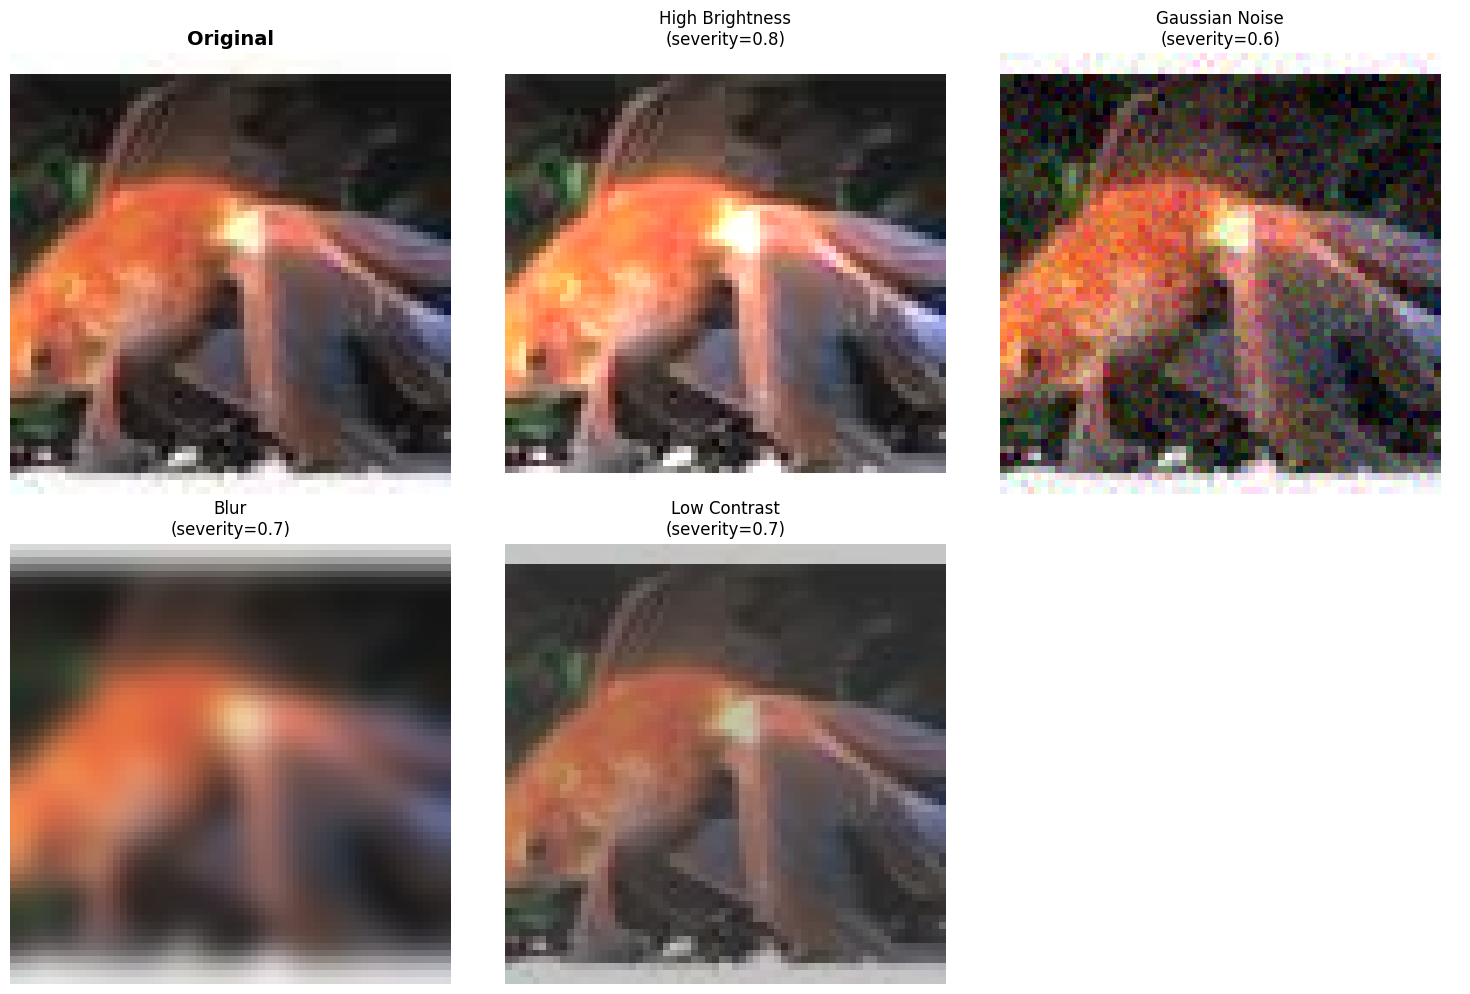

Drift examples saved as 'drift_examples.png'


In [ ]:
# Visualize drift examples
def visualize_drift_examples():
    # Get a sample image
    sample_img_path, label = val_dataset.samples[0]
    original_img = Image.open(sample_img_path).convert('RGB')

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Original
    axes[0, 0].imshow(original_img)
    axes[0, 0].set_title('Original', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')

    # Different drift types
    drift_configs = [
        ('brightness', 0.8, 'High Brightness'),
        ('noise', 0.6, 'Gaussian Noise'),
        ('blur', 0.7, 'Blur'),
        ('contrast', 0.7, 'Low Contrast')
    ]

    for idx, (drift_type, severity, title) in enumerate(drift_configs):
        row = (idx + 1) // 3
        col = (idx + 1) % 3

        # Create drifted dataset
        temp_dataset = ImageFolder('tiny-imagenet-200/val', transform=None)
        drifted = DriftedDataset(temp_dataset, drift_type=drift_type, severity=severity)
        drifted_img, _ = drifted[0]

        axes[row, col].imshow(drifted_img)
        axes[row, col].set_title(f'{title}\n(severity={severity})', fontsize=12)
        axes[row, col].axis('off')

    # Hide last subplot
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.savefig('drift_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Drift examples saved as 'drift_examples.png'")

# Install scipy if needed
!pip install -q scipy

visualize_drift_examples()

### 3.2 Evaluate on Drifted Data and Log to W&B (3 Marks)

In [ ]:
# Load best model for drift testing
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 200)
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

baseline_acc = checkpoint['val_acc']
print(f"Baseline validation accuracy: {baseline_acc:.2f}%")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Baseline validation accuracy: 52.83%


In [ ]:
def evaluate_drifted_data(model, drift_type, severity, device, run_name):
    """Evaluate model on drifted data"""
    # Initialize W&B run
    run = wandb.init(
        project='tiny-imagenet-resnet',
        name=run_name,
        config={
            'drift_type': drift_type,
            'severity': severity,
            'baseline_accuracy': baseline_acc
        },
        tags=['drift', drift_type]
    )

    # Create drifted dataset
    val_dataset_no_transform = ImageFolder('tiny-imagenet-200/val', transform=None)
    drifted_dataset = DriftedDataset(val_dataset_no_transform, drift_type=drift_type, severity=severity)
    drifted_dataset.original_dataset.transform = val_transform

    drifted_loader = DataLoader(drifted_dataset, batch_size=128, shuffle=False, num_workers=2)

    # Evaluate
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(drifted_loader, desc=f'Evaluating {drift_type}'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    accuracy_drop = baseline_acc - accuracy
    drop_percentage = (accuracy_drop / baseline_acc) * 100

    # Log to W&B
    wandb.log({
        'drifted_accuracy': accuracy,
        'baseline_accuracy': baseline_acc,
        'accuracy_drop': accuracy_drop,
        'drop_percentage': drop_percentage,
        'drift_severity': severity
    })

    # Log comparison table
    table = wandb.Table(
        columns=['Metric', 'Value'],
        data=[
            ['Baseline Accuracy (%)', f'{baseline_acc:.2f}'],
            ['Drifted Accuracy (%)', f'{accuracy:.2f}'],
            ['Accuracy Drop (%)', f'{accuracy_drop:.2f}'],
            ['Relative Drop (%)', f'{drop_percentage:.2f}'],
            ['Drift Type', drift_type],
            ['Severity', f'{severity:.2f}']
        ]
    )
    wandb.log({'drift_metrics': table})

    wandb.finish()

    return accuracy, accuracy_drop, drop_percentage

In [ ]:
# Test different drift scenarios
drift_scenarios = [
    ('brightness', 0.5, 'drift-brightness-medium'),
    ('brightness', 0.9, 'drift-brightness-high'),
    ('noise', 0.4, 'drift-noise-medium'),
    ('noise', 0.8, 'drift-noise-high'),
    ('blur', 0.5, 'drift-blur-medium'),
    ('contrast', 0.6, 'drift-contrast-medium'),
]

results = []

print("\n" + "="*80)
print("DRIFT EVALUATION RESULTS")
print("="*80)
print(f"Baseline Accuracy: {baseline_acc:.2f}%\n")

for drift_type, severity, run_name in drift_scenarios:
    print(f"\n{'='*60}")
    print(f"Testing: {drift_type.upper()} (severity={severity})")
    print(f"{'='*60}")

    acc, drop, drop_pct = evaluate_drifted_data(model, drift_type, severity, device, run_name)

    results.append({
        'drift_type': drift_type,
        'severity': severity,
        'accuracy': acc,
        'drop': drop,
        'drop_pct': drop_pct
    })

    print(f"\nResults:")
    print(f"  Drifted Accuracy: {acc:.2f}%")
    print(f"  Accuracy Drop: {drop:.2f}%")
    print(f"  Relative Drop: {drop_pct:.2f}%")

print("\n" + "="*80)
print("All drift evaluations completed!")
print("="*80)


DRIFT EVALUATION RESULTS
Baseline Accuracy: 52.83%


Testing: BRIGHTNESS (severity=0.5)


Evaluating brightness: 100%|██████████| 79/79 [00:09<00:00,  8.69it/s]


accuracy_drop,▁
baseline_accuracy,▁
drift_severity,▁
drifted_accuracy,▁
drop_percentage,▁
accuracy_drop,0
baseline_accuracy,52.83
drift_severity,0.5
drifted_accuracy,52.83
drop_percentage,0



Results:
  Drifted Accuracy: 52.83%
  Accuracy Drop: 0.00%
  Relative Drop: 0.00%

Testing: BRIGHTNESS (severity=0.9)


Evaluating brightness: 100%|██████████| 79/79 [00:06<00:00, 12.28it/s]


...

accuracy_drop,▁
baseline_accuracy,▁
drift_severity,▁
drifted_accuracy,▁
drop_percentage,▁
accuracy_drop,42.64
baseline_accuracy,52.83
drift_severity,0.5
drifted_accuracy,10.19
drop_percentage,80.71172



Results:
  Drifted Accuracy: 10.19%
  Accuracy Drop: 42.64%
  Relative Drop: 80.71%

Testing: CONTRAST (severity=0.6)


Evaluating contrast: 100%|██████████| 79/79 [00:06<00:00, 12.94it/s]


accuracy_drop,▁
baseline_accuracy,▁
drift_severity,▁
drifted_accuracy,▁
drop_percentage,▁
accuracy_drop,1.14
baseline_accuracy,52.83
drift_severity,0.6
drifted_accuracy,51.69
drop_percentage,2.15786



Results:
  Drifted Accuracy: 51.69%
  Accuracy Drop: 1.14%
  Relative Drop: 2.16%

All drift evaluations completed!


### 3.3 Create W&B Alert for Significant Accuracy Drop (4 Marks)

In [ ]:
# Create comprehensive drift monitoring with alerts
def monitor_drift_with_alerts(model, drift_type, severity, alert_threshold=10.0):
    """
    Monitor drift and create alerts when accuracy drops significantly
    alert_threshold: percentage drop that triggers alert (default 10%)
    """
    run = wandb.init(
        project='tiny-imagenet-resnet',
        name=f'drift-monitoring-{drift_type}-{severity}',
        config={
            'drift_type': drift_type,
            'severity': severity,
            'baseline_accuracy': baseline_acc,
            'alert_threshold': alert_threshold
        },
        tags=['drift-monitoring', 'alert', drift_type]
    )

    # Evaluate
    val_dataset_no_transform = ImageFolder('tiny-imagenet-200/val', transform=None)
    drifted_dataset = DriftedDataset(val_dataset_no_transform, drift_type=drift_type, severity=severity)
    drifted_dataset.original_dataset.transform = val_transform
    drifted_loader = DataLoader(drifted_dataset, batch_size=128, shuffle=False, num_workers=2)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(drifted_loader, desc='Monitoring drift'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    accuracy_drop = baseline_acc - accuracy
    drop_percentage = (accuracy_drop / baseline_acc) * 100

    # Check if alert should be triggered
    alert_triggered = accuracy_drop >= alert_threshold

    # Log metrics
    wandb.log({
        'drifted_accuracy': accuracy,
        'baseline_accuracy': baseline_acc,
        'accuracy_drop': accuracy_drop,
        'drop_percentage': drop_percentage,
        'alert_triggered': alert_triggered,
        'alert_threshold': alert_threshold
    })

    # Create alert if threshold exceeded
    if alert_triggered:
        alert_message = f"""🚨 DATA DRIFT ALERT 🚨

Drift Type: {drift_type}
Severity: {severity}

Baseline Accuracy: {baseline_acc:.2f}%
Current Accuracy: {accuracy:.2f}%
Accuracy Drop: {accuracy_drop:.2f}%
Relative Drop: {drop_percentage:.2f}%

⚠️ This exceeds the alert threshold of {alert_threshold}%
Action Required: Investigate data quality and consider model retraining.
        """

        wandb.alert(
            title=f"Data Drift Detected: {drift_type}",
            text=alert_message,
            level=wandb.AlertLevel.WARN
        )

        print("\n" + "="*70)
        print("⚠️  ALERT TRIGGERED ⚠️")
        print("="*70)
        print(alert_message)
        print("="*70)
    else:
        print(f"\n✓ No alert: Accuracy drop ({accuracy_drop:.2f}%) is below threshold ({alert_threshold}%)")

    # Create comparison visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy comparison
    categories = ['Baseline', 'Drifted']
    accuracies = [baseline_acc, accuracy]
    colors = ['green', 'red' if alert_triggered else 'orange']

    bars = ax1.bar(categories, accuracies, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Accuracy Comparison\n{drift_type} (severity={severity})', fontsize=14, fontweight='bold')
    ax1.set_ylim([0, 100])
    ax1.axhline(y=baseline_acc-alert_threshold, color='red', linestyle='--', linewidth=2, label=f'Alert Threshold')
    ax1.legend()

    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Accuracy drop visualization
    metrics = ['Accuracy\nDrop (%)', 'Relative\nDrop (%)']
    values = [accuracy_drop, drop_percentage]
    colors2 = ['red' if alert_triggered else 'orange', 'red' if alert_triggered else 'orange']

    bars2 = ax2.bar(metrics, values, color=colors2, alpha=0.7, edgecolor='black')
    ax2.set_ylabel('Drop (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Accuracy Degradation Metrics', fontsize=14, fontweight='bold')
    ax2.axhline(y=alert_threshold, color='red', linestyle='--', linewidth=2, label=f'Alert Threshold')
    ax2.legend()

    # Add value labels
    for bar, val in zip(bars2, values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()

    # Save and log to W&B
    filename = f'drift_comparison_{drift_type}_{severity}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    wandb.log({"drift_comparison": wandb.Image(filename)})
    plt.show()

    wandb.finish()

    return accuracy, accuracy_drop, alert_triggered

print("Drift monitoring function created!")

Drift monitoring function created!



DRIFT MONITORING WITH ALERTS
Alert Threshold: 10.0% accuracy drop

Monitoring: BRIGHTNESS (severity=0.9)


Monitoring drift: 100%|██████████| 79/79 [00:07<00:00, 11.27it/s]



✓ No alert: Accuracy drop (2.79%) is below threshold (10.0%)


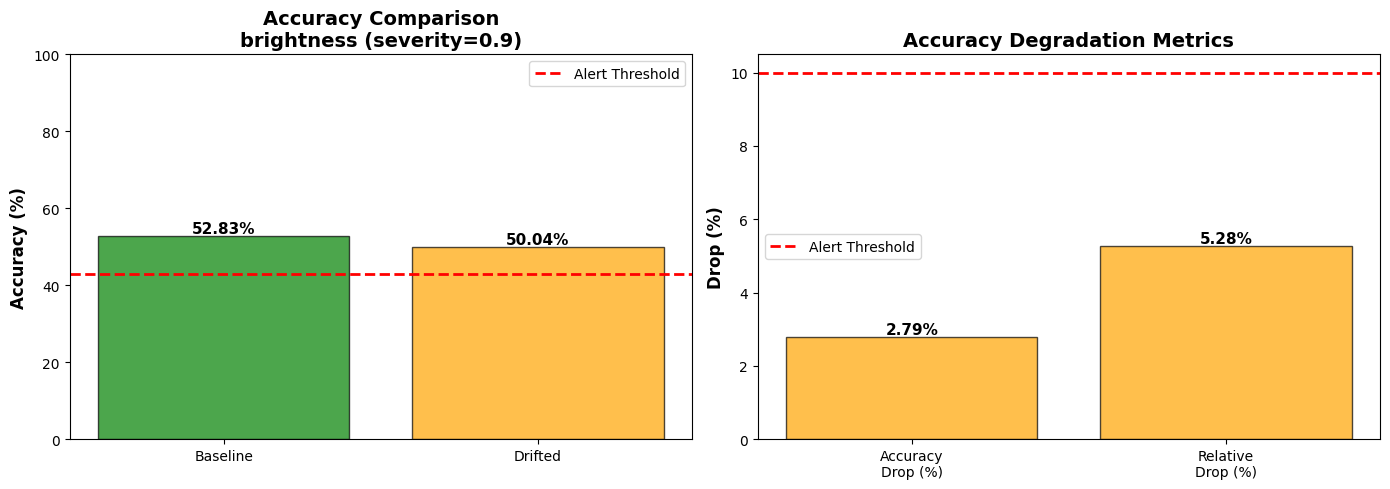

accuracy_drop,▁
alert_threshold,▁
baseline_accuracy,▁
drifted_accuracy,▁
drop_percentage,▁
accuracy_drop,2.79
alert_threshold,10
alert_triggered,False
baseline_accuracy,52.83
drifted_accuracy,50.04
drop_percentage,5.28109



Monitoring: NOISE (severity=0.8)


Monitoring drift: 100%|██████████| 79/79 [00:10<00:00,  7.70it/s]



⚠️  ALERT TRIGGERED ⚠️
🚨 DATA DRIFT ALERT 🚨

Drift Type: noise
Severity: 0.8

Baseline Accuracy: 52.83%
Current Accuracy: 35.23%
Accuracy Drop: 17.60%
Relative Drop: 33.31%

⚠️ This exceeds the alert threshold of 10.0%
Action Required: Investigate data quality and consider model retraining.
        


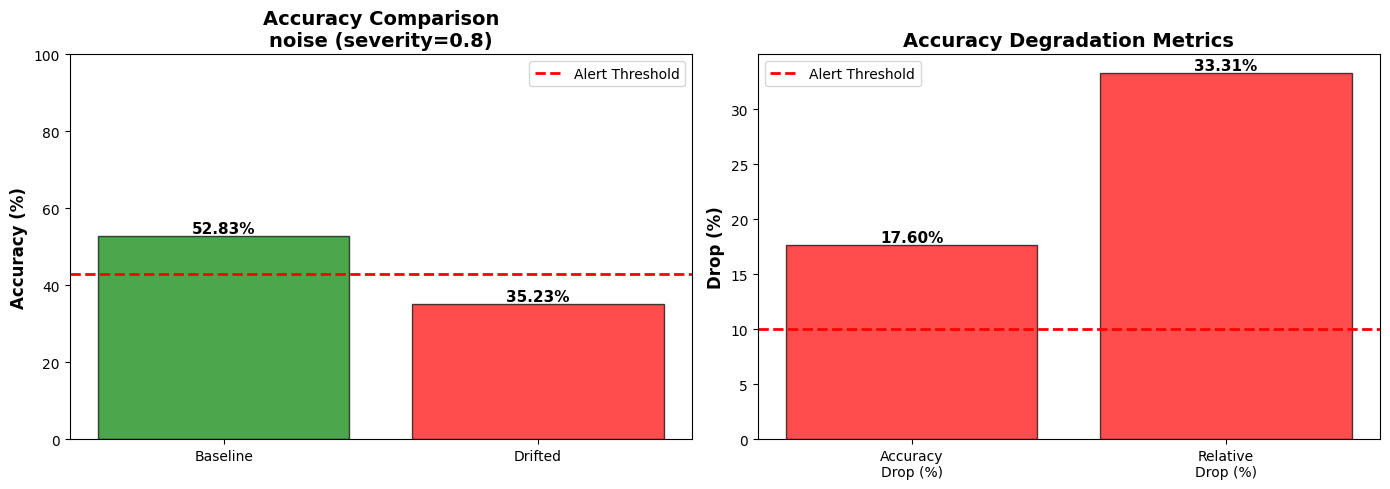

accuracy_drop,▁
alert_threshold,▁
baseline_accuracy,▁
drifted_accuracy,▁
drop_percentage,▁
accuracy_drop,17.6
alert_threshold,10
alert_triggered,True
baseline_accuracy,52.83
drifted_accuracy,35.23
drop_percentage,33.3144



Monitoring: BLUR (severity=0.7)


Monitoring drift: 100%|██████████| 79/79 [00:11<00:00,  7.02it/s]



⚠️  ALERT TRIGGERED ⚠️
🚨 DATA DRIFT ALERT 🚨

Drift Type: blur
Severity: 0.7

Baseline Accuracy: 52.83%
Current Accuracy: 6.69%
Accuracy Drop: 46.14%
Relative Drop: 87.34%

⚠️ This exceeds the alert threshold of 10.0%
Action Required: Investigate data quality and consider model retraining.
        


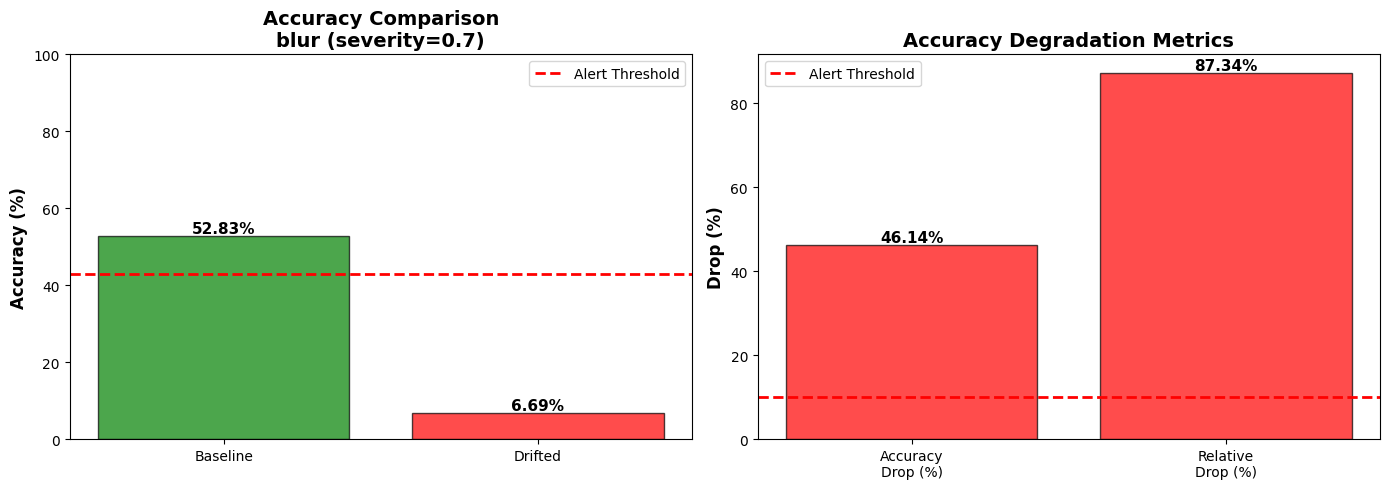

accuracy_drop,▁
alert_threshold,▁
baseline_accuracy,▁
drifted_accuracy,▁
drop_percentage,▁
accuracy_drop,46.14
alert_threshold,10
alert_triggered,True
baseline_accuracy,52.83
drifted_accuracy,6.69
drop_percentage,87.33674



ALERT SUMMARY
Drift Type      Severity   Accuracy     Drop       Alert
--------------------------------------------------------------------------------
brightness      0.90       50.04        2.79       ✓ NO
noise           0.80       35.23        17.60      🚨 YES
blur            0.70       6.69         46.14      🚨 YES


In [ ]:
# Run drift monitoring with alerts
alert_threshold = 10.0  # Alert if accuracy drops by more than 10%

monitoring_scenarios = [
    ('brightness', 0.9),  # Severe brightness change - should trigger alert
    ('noise', 0.8),       # High noise - should trigger alert
    ('blur', 0.7),        # Significant blur - might trigger alert
]

print("\n" + "="*80)
print("DRIFT MONITORING WITH ALERTS")
print(f"Alert Threshold: {alert_threshold}% accuracy drop")
print("="*80)

alert_summary = []

for drift_type, severity in monitoring_scenarios:
    print(f"\n{'='*70}")
    print(f"Monitoring: {drift_type.upper()} (severity={severity})")
    print(f"{'='*70}")

    acc, drop, alerted = monitor_drift_with_alerts(
        model, drift_type, severity, alert_threshold=alert_threshold
    )

    alert_summary.append({
        'drift_type': drift_type,
        'severity': severity,
        'accuracy': acc,
        'drop': drop,
        'alert': '🚨 YES' if alerted else '✓ NO'
    })

print("\n" + "="*80)
print("ALERT SUMMARY")
print("="*80)
print(f"{'Drift Type':<15} {'Severity':<10} {'Accuracy':<12} {'Drop':<10} {'Alert'}")
print("-"*80)
for result in alert_summary:
    print(f"{result['drift_type']:<15} {result['severity']:<10.2f} {result['accuracy']:<12.2f} {result['drop']:<10.2f} {result['alert']}")
print("="*80)

### 3.4 Create Final Drift Report

In [ ]:
# Create comprehensive drift report
import pandas as pd

# Combine all results
# Extract relevant data from both results and alert_summary
combined_results = []

for r in results:
    combined_results.append({
        'drift_type': r['drift_type'],
        'severity': r['severity'],
        'accuracy': r['accuracy'],
        'drop': r['drop'],
        'drop_pct': r['drop_pct']
    })

for r in alert_summary:
    combined_results.append({
        'drift_type': r['drift_type'],
        'severity': r['severity'],
        'accuracy': r['accuracy'],
        'drop': r['drop'],
        # Add 'drop_pct' to alert_summary items if it's missing or calculate it
        'drop_pct': r.get('drop_pct', (baseline_acc - r['accuracy']) / baseline_acc * 100 if baseline_acc != 0 else 0)
    })


# Create DataFrame
df_results = pd.DataFrame(combined_results)

# Create final report
report = f"""
{'='*80}
DATA DRIFT ANALYSIS REPORT
Tiny ImageNet - ResNet18
{'='*80}

BASELINE PERFORMANCE
{'-'*80}
Model: ResNet18 (Pretrained on ImageNet, Fine-tuned on Tiny ImageNet)
Baseline Validation Accuracy: {baseline_acc:.2f}%
Dataset: Tiny ImageNet (200 classes, 64x64 images)

DRIFT SCENARIOS TESTED
{'-'*80}
{df_results.to_string(index=False)}

KEY FINDINGS
{'-'*80}
1. Most Severe Impact: {df_results.loc[df_results['drop'].idxmax(), 'drift_type']}
   (Severity: {df_results.loc[df_results['drop'].idxmax(), 'severity']:.2f},
   Drop: {df_results['drop'].max():.2f}%)

2. Least Impact: {df_results.loc[df_results['drop'].idxmin(), 'drift_type']}
   (Severity: {df_results.loc[df_results['drop'].idxmin(), 'severity']:.2f},
   Drop: {df_results['drop'].min():.2f}%)

3. Average Accuracy Drop: {df_results['drop'].mean():.2f}%

4. Alert Threshold: {alert_threshold}%
   Scenarios Triggering Alert: {len([r for r in alert_summary if '🚨' in r['alert']])}

RECOMMENDATIONS
{'-'*80}
• Monitor production data for brightness and noise variations
• Implement data quality checks before inference
• Consider data augmentation with similar drift patterns during training
• Set up automated alerting when accuracy drops below {baseline_acc - alert_threshold:.2f}%
• Retrain model when significant drift is detected

WEIGHTS & BIASES DASHBOARD
{'-'*80}
• All metrics logged to W&B project: 'tiny-imagenet-resnet'
• View comparisons, loss curves, and drift analysis in W&B dashboard
• Alerts configured for accuracy drops exceeding {alert_threshold}%

{'='*80}
Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

print(report)

# Save report
with open('drift_analysis_report.txt', 'w') as f:
    f.write(report)

print("\n✓ Report saved as 'drift_analysis_report.txt'")


DATA DRIFT ANALYSIS REPORT
Tiny ImageNet - ResNet18

BASELINE PERFORMANCE
--------------------------------------------------------------------------------
Model: ResNet18 (Pretrained on ImageNet, Fine-tuned on Tiny ImageNet)
Baseline Validation Accuracy: 52.83%
Dataset: Tiny ImageNet (200 classes, 64x64 images)

DRIFT SCENARIOS TESTED
--------------------------------------------------------------------------------
drift_type  severity  accuracy  drop  drop_pct
brightness       0.5     52.83  0.00  0.000000
brightness       0.9     50.04  2.79  5.281090
     noise       0.4     49.21  3.62  6.852167
     noise       0.8     35.45 17.38 32.897975
      blur       0.5     10.19 42.64 80.711717
  contrast       0.6     51.69  1.14  2.157865
brightness       0.9     50.04  2.79  5.281090
     noise       0.8     35.23 17.60 33.314405
      blur       0.7      6.69 46.14 87.336740

KEY FINDINGS
--------------------------------------------------------------------------------
1. Most Severe I

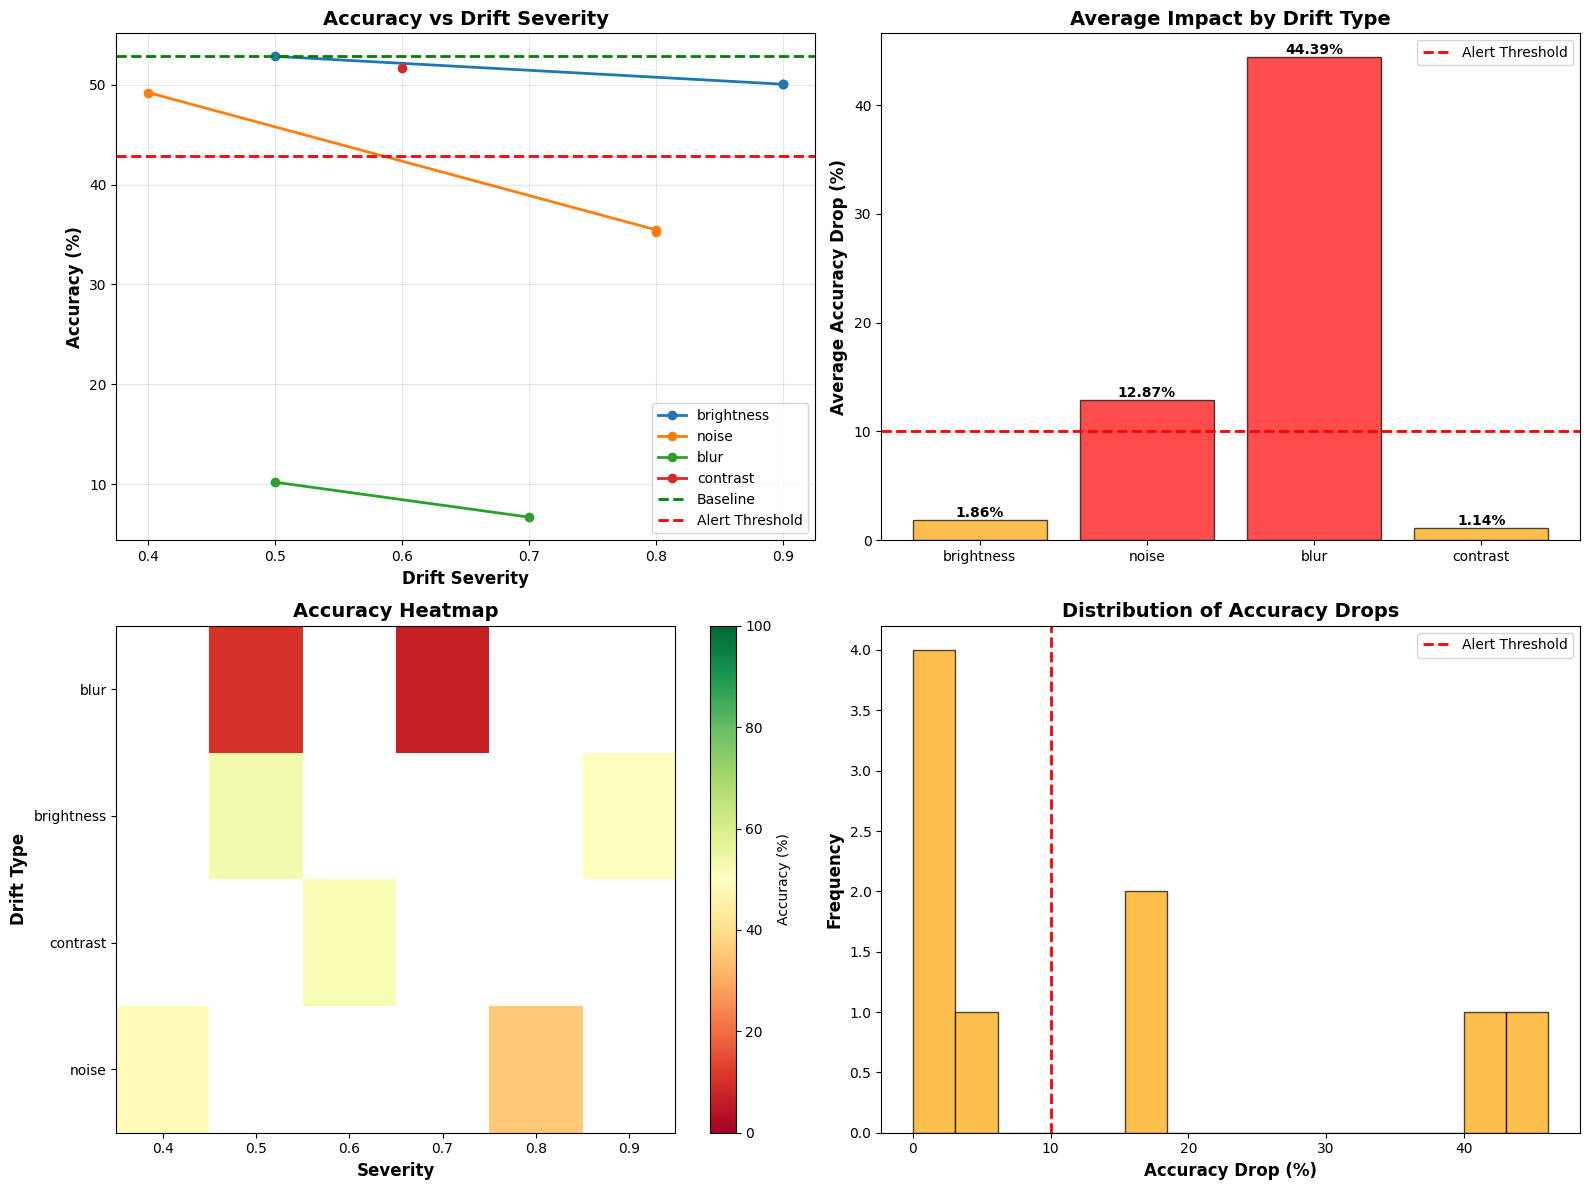

✓ Comprehensive drift analysis visualization saved as 'comprehensive_drift_analysis.png'


In [ ]:
# Create final visualization comparing all drift scenarios
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy by drift type and severity
ax1 = axes[0, 0]
for drift_type in df_results['drift_type'].unique():
    data = df_results[df_results['drift_type'] == drift_type]
    ax1.plot(data['severity'], data['accuracy'], marker='o', linewidth=2, label=drift_type)
ax1.axhline(y=baseline_acc, color='green', linestyle='--', linewidth=2, label='Baseline')
ax1.axhline(y=baseline_acc-alert_threshold, color='red', linestyle='--', linewidth=2, label='Alert Threshold')
ax1.set_xlabel('Drift Severity', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy vs Drift Severity', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Accuracy drop by drift type
ax2 = axes[0, 1]
drift_types = df_results['drift_type'].unique()
avg_drops = [df_results[df_results['drift_type'] == dt]['drop'].mean() for dt in drift_types]
colors_bar = ['red' if drop > alert_threshold else 'orange' for drop in avg_drops]
bars = ax2.bar(drift_types, avg_drops, color=colors_bar, alpha=0.7, edgecolor='black')
ax2.axhline(y=alert_threshold, color='red', linestyle='--', linewidth=2, label='Alert Threshold')
ax2.set_ylabel('Average Accuracy Drop (%)', fontsize=12, fontweight='bold')
ax2.set_title('Average Impact by Drift Type', fontsize=14, fontweight='bold')
ax2.legend()
for bar, drop in zip(bars, avg_drops):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{drop:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Heatmap of accuracy by drift type and severity
ax3 = axes[1, 0]
pivot_data = df_results.pivot_table(values='accuracy', index='drift_type', columns='severity', aggfunc='mean')
im = ax3.imshow(pivot_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax3.set_xticks(range(len(pivot_data.columns)))
ax3.set_xticklabels([f'{x:.1f}' for x in pivot_data.columns])
ax3.set_yticks(range(len(pivot_data.index)))
ax3.set_yticklabels(pivot_data.index)
ax3.set_xlabel('Severity', fontsize=12, fontweight='bold')
ax3.set_ylabel('Drift Type', fontsize=12, fontweight='bold')
ax3.set_title('Accuracy Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax3, label='Accuracy (%)')

# 4. Distribution of accuracy drops
ax4 = axes[1, 1]
ax4.hist(df_results['drop'], bins=15, color='orange', alpha=0.7, edgecolor='black')
ax4.axvline(x=alert_threshold, color='red', linestyle='--', linewidth=2, label='Alert Threshold')
ax4.set_xlabel('Accuracy Drop (%)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Distribution of Accuracy Drops', fontsize=14, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.savefig('comprehensive_drift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Comprehensive drift analysis visualization saved as 'comprehensive_drift_analysis.png'")